# Homework for Lab 3.8

In [1]:
import os
import numpy as np
import torch

device = 'cpu'
torch.manual_seed(42)
np.random.seed(42)

if torch.cuda.is_available():
  device = 'cuda'
  torch.cuda.manual_seed(42)
  torch.cuda.manual_seed_all(42)
  torch.backends.cuda.matmul.allow_tf32 = True
  torch.backends.cudnn.allow_tf32 = True

print(f"Using device: {device}")

Using device: cuda


## 3.8.1 Positional Encoding is (not?) All You Need

##### Dataset

In [49]:
from datasets import load_dataset

dataset = load_dataset("fancyzhx/ag_news")

# split train dataset into training and validation
temp = dataset["train"].train_test_split(test_size=0.2)
dataset['val'] = temp['test']
dataset['train'] = temp['train']
del temp

ag_news_labels = {0: "World",
                 1: "Sports",
                 2: "Business",
                 3: "Sci/Tec"}

In [50]:
import re

def normalize_string(s):
    """Normalize a string by lowercasing, trimming, and removing non-letter characters.

    Args:
        s (str): The input string to normalize.

    Returns:
        str: The normalized string.
    """
    s = s.lower().strip()
    # regex to replace any non-letter characters by white space
    s = re.sub(r"[^a-zA-Z!?]+", r" ", s)
    return s.strip()

def tokenize_and_trim(dataset, max_length=300):
    """ Tokenizes and trims the text in the dataset.
    Text is split at any whitespace character and trimmed to `max_length` number of tokens.

    Args:
        dataset (dict): A dictionary containing the dataset with a 'text' field.
        max_length (int, optional): Maximum number of tokens to keep. Defaults to 300.

    Returns:
        dict: A dictionary with 'text' field containing tokenized and trimmed text.
    """
    normalized_texts = [normalize_string(text) for text in dataset['text']]
    return {
        'text': [text.split()[:max_length] for text in normalized_texts]
        }

dataset['train'] = dataset['train'].map(tokenize_and_trim, batched=True)
dataset['val'] = dataset['val'].map(tokenize_and_trim, batched=True)
dataset['test'] = dataset['test'].map(tokenize_and_trim, batched=True)

Map:   0%|          | 0/96000 [00:00<?, ? examples/s]

Map:   0%|          | 0/24000 [00:00<?, ? examples/s]

In [4]:
from tqdm.notebook import tqdm

class Vocabulary:
    """ A simple vocabulary class that builds a mapping from tokens to indices and vice versa.
    """

    def __init__(self, max_size):
        """ Initializes the vocabulary with a maximum size.
        Args:
            max_size (int): The maximum number of tokens to keep in the vocabulary.
        """
        self.max_size = max_size
        self.tokens_to_idx = {'<PAD>': 0, '<UNK>': 1}
        self.idx_to_tokens = {v:k for k,v in self.tokens_to_idx.items()}
        assert len(self.tokens_to_idx) == len(self.idx_to_tokens)

    def __len__(self):
        return len(self.tokens_to_idx)

    def build_vocabulary(self, dataset):
        """ Builds the vocabulary from the dataset.
        It counts the frequency of each token in the dataset and keeps the `max_size` most frequent tokens.
        Args:
            dataset (_type_): The dataset to build the vocabulary from.
        """
        print("Building vocabulary...")
        frequencies = {}
        idx = 2
        for sample in tqdm(dataset['text']):
            for word in sample:
                if word in frequencies:
                    frequencies[word] += 1
                else:
                    frequencies[word] = 1

        # keep `max_size` most frequent words
        frequencies = sorted(
            frequencies.items(),
            key=lambda item: item[1],
            reverse=True
        )

        for word, freq in frequencies[:self.max_size]:
            self.tokens_to_idx[word] = idx
            self.idx_to_tokens[idx] = word
            idx += 1

    def encode(self, sample):
        """ Encodes a sample (list of tokens) into a list of indices.
        If a token is not in the vocabulary, it is replaced by the index of the `<UNK>` token.
        Args:
            sample (list): A list of tokens to encode.
        Returns:
            list: A list of indices corresponding to the tokens in the sample.
        """
        encoded = []
        for word in sample:
            if word in self.tokens_to_idx.keys():
                encoded.append(self.tokens_to_idx[word])
            else:
                encoded.append(self.tokens_to_idx['<UNK>'])
        return encoded

In [5]:
vocab = Vocabulary(max_size=20000)
vocab.build_vocabulary(dataset['train'])

Building vocabulary...


  0%|          | 0/96000 [00:00<?, ?it/s]

In [6]:
def encode_dataset(dataset):
    return {
        'encoded': [vocab.encode(text) for text in dataset['text']]
        }

dataset['train'] = dataset['train'].map(encode_dataset, batched=True)
dataset['val'] = dataset['val'].map(encode_dataset, batched=True)
dataset['test'] = dataset['test'].map(encode_dataset, batched=True)

In [7]:
from torch.utils.data import TensorDataset
import torch.nn.functional as F


def create_tensordataset(dataset):
    inputs = torch.nn.utils.rnn.pad_sequence(
        [torch.tensor(d) for d in dataset['encoded']],
        batch_first=True,
        padding_value=0,
        ### START YOUR CODE HERE ###
        # 'left' or 'right'?
        padding_side= 'left' # doesn't matter
        ### END YOUR CODE HERE ###
    )

    targets = torch.Tensor(dataset['label']).long()

    return TensorDataset(inputs.to(device), targets.to(device))

train_ds = create_tensordataset(dataset['train'])
val_ds = create_tensordataset(dataset['val'])
test_ds = create_tensordataset(dataset['test'])

In [8]:
from torch.utils.data import DataLoader

BATCH_SIZE = 512

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE)

In [9]:
import torch
import torch.nn as nn
import math

class MultiHeadSelfAttention(nn.Module):
    ''' Multi-head self attention layer consisting of four parts:
      - linear layers and separation into multiple heads
      - scaled dot product attention
      - concatenation of multiple heads
      - final linear layer
    '''

    def __init__(self, hidden_size, num_heads):
        super().__init__()
        assert hidden_size % num_heads == 0, "hidden_size must be divisible by num_heads"

        self.hidden_size = hidden_size
        self.num_heads = num_heads           # Number of attention heads
        self.d_k = hidden_size // num_heads  # Dimension of each head's key, query, and value

        # Layers for query, key, and value
        ### START YOUR CODE HERE ###
        self.query_linear = nn.LazyLinear(hidden_size)
        self.key_linear = nn.LazyLinear(hidden_size)
        self.value_linear = nn.LazyLinear(hidden_size)
        ### END YOUR CODE HERE ###
        self.output_linear = nn.LazyLinear(hidden_size)

    def attention(self, query, key, value, mask=None):
        ''' Compute scaled dot product attention

        Args:
          query : Tensor with shape (batch_size, num_heads, sequence_length, hidden_size/num_heads)
          key : Tensor with shape (batch_size, num_heads, sequence_length, hidden_size/num_heads)
          value : Tensor with shape (batch_size, num_heads, sequence_length, hidden_size/num_heads)
          mask : Tensor with shape (batch_size, 1, sequence_length, sequence_length) or None

        Returns:
          Tensor with shape (batch_size, num_heads, sequence_length, hidden_size/num_heads)
        '''

        # compute dot product attention
        scores = torch.matmul(query, key.transpose(-2, -1)) / math.sqrt(self.d_k)

        # apply mask (if provided) - useful to prevent attending to padding tokens or future tokens in decoder
        if mask is not None:
            scores = scores.masked_fill(mask == 0, -1e9)

        # apply softmax
        attn_weights = torch.softmax(scores, dim=-1)

        return torch.matmul(attn_weights, value)


    def separate_heads(self, x, batch_size):
        ''' Separate x into different heads and transpose resulting value.

        Args:
          x : Tensor with shape (batch_size, sequence_length, hidden_size)

        Returns:
          Tensor with shape (batch_size, num_heads, sequence_length, hidden_size/num_heads)
        '''
        x = x.view(batch_size, -1, self.num_heads, self.d_k)
        return x.transpose(1, 2)

    def combine_heads(self, x, batch_size):
        ''' Combine splitted tensor.

        Args:
          x : Tensor with shape (batch_size, num_heads, sequence_length, hidden_size/num_heads)

        Returns:
          Tensor with shape (batch_size, sequence_length, hidden_size)
        '''
        x = x.transpose(1, 2).contiguous()
        return x.view(batch_size, -1, self.hidden_size)

    def forward(self, x, mask=None):
        ''' Apply self-attention mechanism to inputs.

        Args:
          inputs : Tensor with shape (batch_size, sequence_length, hidden_size)
          mask : Tensor with shape (batch_size, 1, sequence_length, sequence_length) or None

        Returns:
          Tensor with shape (batch_size, sequence_length, hidden_size)
        '''
        batch_size = x.size(0)

        # compute query, key, and value
        query = self.query_linear(x)
        key = self.key_linear(x)
        value = self.value_linear(x)

        # separate q, k, v across heads
        query = self.separate_heads(query, batch_size)
        key = self.separate_heads(key, batch_size)
        value = self.separate_heads(value, batch_size)

        # compute scaled dot-product attention
        attn = self.attention(query, key, value, mask)

        # combine heads
        combined = self.combine_heads(attn, batch_size)

        # apply final linear layer
        output = self.output_linear(combined)

        return output

#### Encoder Model


In [10]:
class EncoderLayer(nn.Module):
    def __init__(self, embedding_dim, ff_dim, num_heads, dropout=0.1):
        super().__init__()
        self.attention = MultiHeadSelfAttention(embedding_dim, num_heads)
        self.ffn = nn.Sequential(
            nn.Linear(embedding_dim, ff_dim),
            nn.ReLU(),
            nn.Linear(ff_dim, embedding_dim)
        )
        self.norm1 = nn.LayerNorm(embedding_dim)
        self.norm2 = nn.LayerNorm(embedding_dim)
        self.dropout1 = nn.Dropout(dropout)
        self.dropout2 = nn.Dropout(dropout)

    def forward(self, x, mask=None):
        ### START YOUR CODE HERE ###
        output = self.attention(x)
        output = self.dropout1(output)
        x = x + self.norm1(output)

        output = self.ffn(x)
        output = self.dropout2(output)
        x = x + self.norm2(output)
        ### END YOUR CODE HERE ###
        return x

### Positional encoding

In [16]:
class PositionalEncoding(nn.Module):
    def __init__(self, max_len, d_model):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len).unsqueeze(1).float()
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))

        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)

        pe = pe.unsqueeze(0)
        self.register_buffer("pe", pe)

    def forward(self, x):
        return x + self.pe[:, :x.size(1)]

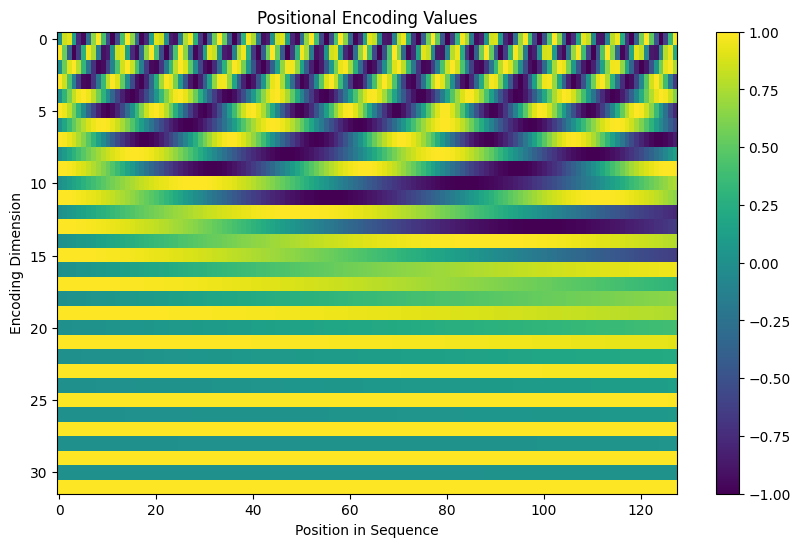

In [12]:
import matplotlib.pyplot as plt

max_len = 128  # Max sequence length to plot
embedding_dim = 32

pe_layer = PositionalEncoding(max_len, embedding_dim)
pe_values = pe_layer.pe.squeeze(0).cpu().numpy()

plt.figure(figsize=(10, 6))
plt.imshow(pe_values.T, aspect='auto')
plt.colorbar()
plt.title("Positional Encoding Values")
plt.xlabel("Position in Sequence")
plt.ylabel("Encoding Dimension")
plt.show()

In [13]:
class TransformerClassifier(nn.Module):
    def __init__(self, vocabulary, max_len, embedding_dim, num_heads, ff_dim, num_encoder_layers, num_classes, droprate=0.1, encoding = 'positional'):
        super().__init__()

        self.embedding = nn.Embedding(len(vocabulary), embedding_dim)

        if encoding == 'learnable':
            self.pos_encoding = nn.Embedding(max_len, embedding_dim)
        elif encoding == 'not_positionnal':
            self.pos_encoding = None
            pass
        else:
            self.pos_encoding = PositionalEncoding(max_len, embedding_dim)

        self.encoders = nn.ModuleList(
            [
                EncoderLayer(embedding_dim, ff_dim, num_heads, dropout=droprate)
                for _ in range(num_encoder_layers)
            ]
        )
        self.pool = nn.AdaptiveAvgPool1d(1)
        self.dropout = nn.Dropout(droprate)
        self.fc1 = nn.Linear(embedding_dim, embedding_dim)
        self.fc2 = nn.Linear(embedding_dim, num_classes)

    def forward(self, x, mask = None):
        ### START YOUR CODE HERE ###
        x = self.embedding(x)
        if not self.pos_encoding is None:
            x = self.pos_encoding(x)

        for encoder in self.encoders:
            x = encoder(x, mask)
        
        ### END YOUR CODE HERE ###
        x = x.transpose(1, 2)
        x = self.pool(x).squeeze(-1)
        x = self.dropout(torch.relu(self.fc1(x)))
        return self.fc2(self.dropout(x))

In [14]:
# Get one batch of samples
inputs, targets = next(iter(train_loader))

# Model parameters
VOCAB_SIZE = len(vocab)
MAX_LEN = inputs.shape[1]

EMBED_DIM = 32
NUM_HEADS = 4 # Number of attention heads
NUM_LAYERS = 2 # Number of encoder layers
FF_DIM = 32 # Dimension of the feedforward network
DROPOUT = 0.2
NUM_CLASSES = 4

EPOCHS = 5
LEARNING_RATE = 1e-3

model_pos = TransformerClassifier(
    vocabulary=vocab,
    max_len=MAX_LEN,
    embedding_dim=EMBED_DIM,
    num_heads=NUM_HEADS,
    ff_dim=FF_DIM,
    num_encoder_layers=NUM_LAYERS,
    num_classes=NUM_CLASSES,
    droprate=DROPOUT
).to(device)

loss_fn = nn.CrossEntropyLoss()
optimizer_pos = torch.optim.Adam(model_pos.parameters(), lr=LEARNING_RATE)

print(model_pos)

TransformerClassifier(
  (embedding): Embedding(20002, 32)
  (pos_encoding): PositionalEncoding()
  (encoders): ModuleList(
    (0-1): 2 x EncoderLayer(
      (attention): MultiHeadSelfAttention(
        (query_linear): LazyLinear(in_features=0, out_features=32, bias=True)
        (key_linear): LazyLinear(in_features=0, out_features=32, bias=True)
        (value_linear): LazyLinear(in_features=0, out_features=32, bias=True)
        (output_linear): LazyLinear(in_features=0, out_features=32, bias=True)
      )
      (ffn): Sequential(
        (0): Linear(in_features=32, out_features=32, bias=True)
        (1): ReLU()
        (2): Linear(in_features=32, out_features=32, bias=True)
      )
      (norm1): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
      (norm2): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
      (dropout1): Dropout(p=0.2, inplace=False)
      (dropout2): Dropout(p=0.2, inplace=False)
    )
  )
  (pool): AdaptiveAvgPool1d(output_size=1)
  (dropout): Dropou

### Trainable positionnal

In [15]:
# Get one batch of samples
inputs, targets = next(iter(train_loader))

# Model parameters
VOCAB_SIZE = len(vocab)
MAX_LEN = inputs.shape[1]

EMBED_DIM = 32
NUM_HEADS = 4 # Number of attention heads
NUM_LAYERS = 2 # Number of encoder layers
FF_DIM = 32 # Dimension of the feedforward network
DROPOUT = 0.2
NUM_CLASSES = 4

EPOCHS = 5
LEARNING_RATE = 1e-3

model_trainable = TransformerClassifier(
    vocabulary=vocab,
    max_len=MAX_LEN,
    embedding_dim=EMBED_DIM,
    num_heads=NUM_HEADS,
    ff_dim=FF_DIM,
    num_encoder_layers=NUM_LAYERS,
    num_classes=NUM_CLASSES,
    droprate=DROPOUT,
    encoding = 'trainable'
).to(device)

loss_fn = nn.CrossEntropyLoss()
optimizer_trainable = torch.optim.Adam(model_trainable.parameters(), lr=LEARNING_RATE)

print(model_trainable)

TransformerClassifier(
  (embedding): Embedding(20002, 32)
  (pos_encoding): PositionalEncoding()
  (encoders): ModuleList(
    (0-1): 2 x EncoderLayer(
      (attention): MultiHeadSelfAttention(
        (query_linear): LazyLinear(in_features=0, out_features=32, bias=True)
        (key_linear): LazyLinear(in_features=0, out_features=32, bias=True)
        (value_linear): LazyLinear(in_features=0, out_features=32, bias=True)
        (output_linear): LazyLinear(in_features=0, out_features=32, bias=True)
      )
      (ffn): Sequential(
        (0): Linear(in_features=32, out_features=32, bias=True)
        (1): ReLU()
        (2): Linear(in_features=32, out_features=32, bias=True)
      )
      (norm1): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
      (norm2): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
      (dropout1): Dropout(p=0.2, inplace=False)
      (dropout2): Dropout(p=0.2, inplace=False)
    )
  )
  (pool): AdaptiveAvgPool1d(output_size=1)
  (dropout): Dropou

### Not positionnal

In [16]:
# Get one batch of samples
inputs, targets = next(iter(train_loader))

# Model parameters
VOCAB_SIZE = len(vocab)
MAX_LEN = inputs.shape[1]

EMBED_DIM = 32
NUM_HEADS = 4 # Number of attention heads
NUM_LAYERS = 2 # Number of encoder layers
FF_DIM = 32 # Dimension of the feedforward network
DROPOUT = 0.2
NUM_CLASSES = 4

EPOCHS = 5
LEARNING_RATE = 1e-3

model_nopos = TransformerClassifier(
    vocabulary=vocab,
    max_len=MAX_LEN,
    embedding_dim=EMBED_DIM,
    num_heads=NUM_HEADS,
    ff_dim=FF_DIM,
    num_encoder_layers=NUM_LAYERS,
    num_classes=NUM_CLASSES,
    droprate=DROPOUT,
    encoding = 'not_positionnal'
).to(device)

loss_fn = nn.CrossEntropyLoss()
optimizer_nopos = torch.optim.Adam(model_nopos.parameters(), lr=LEARNING_RATE)

print(model_nopos)

TransformerClassifier(
  (embedding): Embedding(20002, 32)
  (encoders): ModuleList(
    (0-1): 2 x EncoderLayer(
      (attention): MultiHeadSelfAttention(
        (query_linear): LazyLinear(in_features=0, out_features=32, bias=True)
        (key_linear): LazyLinear(in_features=0, out_features=32, bias=True)
        (value_linear): LazyLinear(in_features=0, out_features=32, bias=True)
        (output_linear): LazyLinear(in_features=0, out_features=32, bias=True)
      )
      (ffn): Sequential(
        (0): Linear(in_features=32, out_features=32, bias=True)
        (1): ReLU()
        (2): Linear(in_features=32, out_features=32, bias=True)
      )
      (norm1): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
      (norm2): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
      (dropout1): Dropout(p=0.2, inplace=False)
      (dropout2): Dropout(p=0.2, inplace=False)
    )
  )
  (pool): AdaptiveAvgPool1d(output_size=1)
  (dropout): Dropout(p=0.2, inplace=False)
  (fc1): Linear

In [17]:
# Get one batch
inputs, targets = next(iter(train_loader))
print(f"Input shape: {inputs.shape}")

# Forward pass
outputs_pos = model_pos(inputs)
outputs_trainable = model_trainable(inputs)
outputs_nopos = model_nopos(inputs)

# Print shapes
print(f"outputs_pos shape: {outputs_pos.shape}")
print(f"Target shape: {targets.shape}")

print(f"outputs_trainable shape: {outputs_trainable.shape}")
print(f"Target shape: {targets.shape}")

print(f"outputs_nopos shape: {outputs_nopos.shape}")
print(f"Target shape: {targets.shape}")

Input shape: torch.Size([512, 180])
outputs_pos shape: torch.Size([512, 4])
Target shape: torch.Size([512])
outputs_trainable shape: torch.Size([512, 4])
Target shape: torch.Size([512])
outputs_nopos shape: torch.Size([512, 4])
Target shape: torch.Size([512])


In [18]:
def plot_sequence_embedding(input_sequence, model):

    input_sequence = input_sequence.unsqueeze(0) # Add batch dimension back
    print(f"Sample input sequence shape: {input_sequence.shape}")

    # Get the embedding layer from the model
    embedding_layer = model.embedding

    # Get the positional encoding layer from the model
    pos_encoding_layer = model.pos_encoding

    # Get the initial token embeddings
    initial_embeddings = embedding_layer(input_sequence)
    print(f"Initial embeddings shape: {initial_embeddings.shape}")

    # Apply positional encoding
    embeddings_with_pe = pos_encoding_layer(initial_embeddings)
    print(f"Embeddings with PE shape: {embeddings_with_pe.shape}")

    # --- Visualization for the entire sequence ---

    # Convert tensors to numpy arrays for plotting
    initial_embeddings_np = initial_embeddings[0].detach().cpu().numpy()
    embeddings_with_pe_np = embeddings_with_pe[0].detach().cpu().numpy()

    fig, axes = plt.subplots(2, 1, figsize=(18, 7))

    # Plot initial embeddings (full sequence)
    im1 = axes[0].imshow(initial_embeddings_np.T, aspect='auto')
    axes[0].set_title('Initial Embeddings (Full Sequence)')
    axes[0].set_xlabel('Token Position')
    axes[0].set_ylabel('Embedding Dimension')
    fig.colorbar(im1, ax=axes[0])

    # Plot embeddings with positional encoding (full sequence)
    im2 = axes[1].imshow(embeddings_with_pe_np.T, aspect='auto')
    axes[1].set_title('Embeddings + Positional Encoding (Full Sequence)')
    axes[1].set_xlabel('Token Position')
    axes[1].set_ylabel('Embedding Dimension')
    fig.colorbar(im2, ax=axes[1])

    plt.tight_layout()
    plt.show()

Input sequence shape: torch.Size([180])
Sample input sequence shape: torch.Size([1, 180])
Initial embeddings shape: torch.Size([1, 180, 32])
Embeddings with PE shape: torch.Size([1, 180, 32])


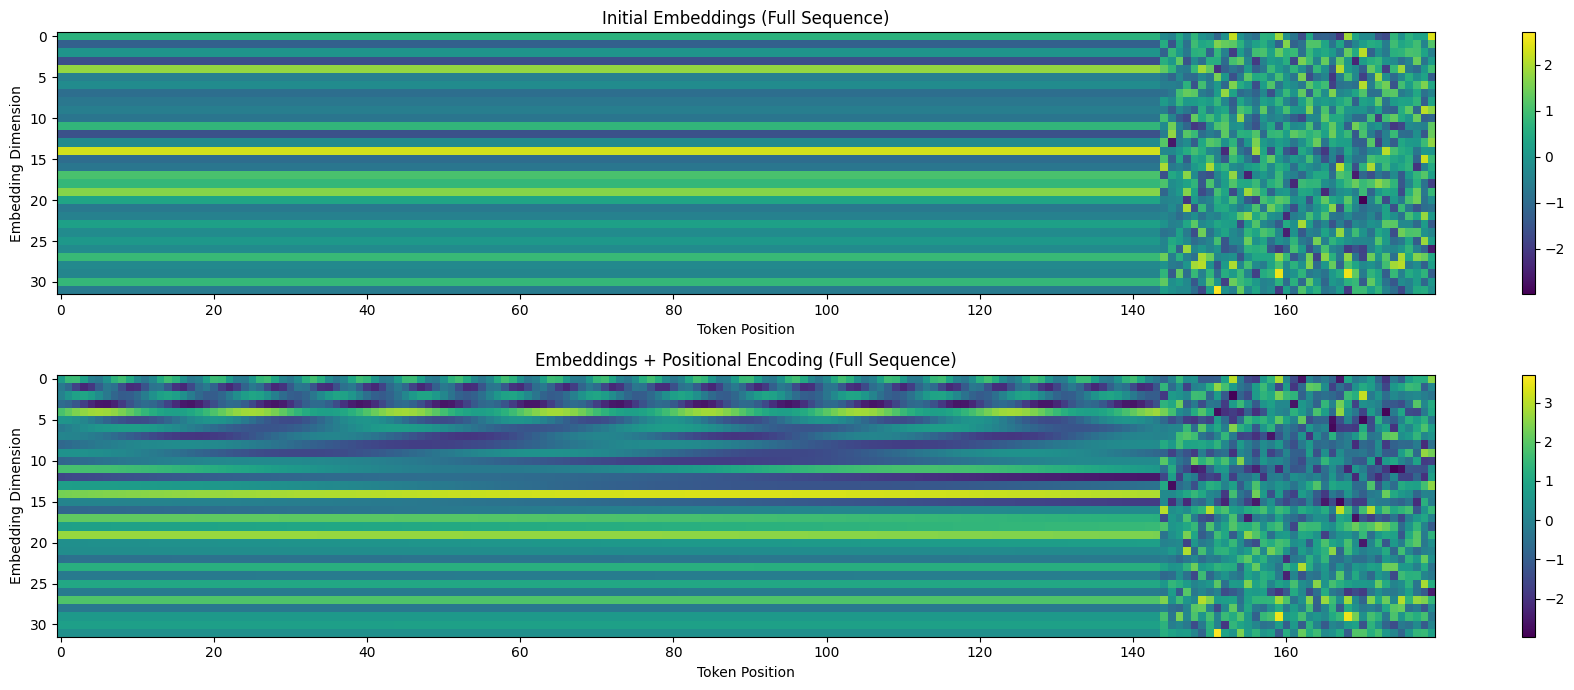

In [19]:
input_sequence = inputs[0]
print(f"Input sequence shape: {input_sequence.shape}")

plot_sequence_embedding(input_sequence, model_pos)


#### Training and evaluation


In [20]:
#@title Trainloop
from tqdm.notebook import tqdm
from matplotlib import pyplot as plt

def train_model_with_validation(model, optimizer, loss_fn, train_loader, val_loader, num_epochs=5, scheduler=None, model_type = 'pos'):
    model.train()
    history = {}
    history[model_type] = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': [], 'lr': []}

    for epoch in range(num_epochs):
        model.train()
        train_epoch_loss = 0.0
        correct_train = 0
        total_train = 0
        for data, targets in tqdm(train_loader, desc=f"Epoch {epoch+1} Training"):
            # generate a mask for padding tokens broadcastable to (batch_size, num_heads, sequence_length, sequence_length)
            # (data != 0) creates a boolean mask (batch_size, sequence_length)
            # .unsqueeze(1) -> (batch_size, 1, sequence_length)
            # .unsqueeze(2) -> (batch_size, 1, 1, sequence_length) which is broadcastable for key dimension masking
            padding_mask = (data != 0).unsqueeze(1).unsqueeze(2)

            logits = model(data, mask=padding_mask)
            running_loss = loss_fn(logits, targets)

            optimizer.zero_grad()
            running_loss.backward()
            optimizer.step()
            if scheduler is not None:
                scheduler.step()

            train_epoch_loss += running_loss.item()

            _, predicted = torch.max(logits.data, 1)
            total_train += targets.size(0)
            correct_train += (predicted == targets).sum().item()


        history[model_type]['train_loss'].append(train_epoch_loss / len(train_loader))
        history[model_type]['train_acc'].append(100 * correct_train / total_train)
        history[model_type]['lr'].append(optimizer.param_groups[0]['lr'])


        model.eval()
        val_epoch_loss = 0.0
        correct_val = 0
        total_val = 0
        with torch.no_grad():
            for data, targets in tqdm(val_loader, desc=f"Epoch {epoch+1} Validation"):
                padding_mask = (data != 0).unsqueeze(1).unsqueeze(2)
                logits = model(data, mask=padding_mask)
                running_loss = loss_fn(logits, targets)
                val_epoch_loss += running_loss.item()

                _, predicted = torch.max(logits.data, 1)
                total_val += targets.size(0)
                correct_val += (predicted == targets).sum().item()

        history[model_type]['val_loss'].append(val_epoch_loss / len(val_loader))
        history[model_type]['val_acc'].append(100 * correct_val / total_val)

        print(f"Epoch {epoch + 1}/{num_epochs}",
              f"| Train Loss: {history[model_type]['train_loss'][-1]:.4f}",
              f"| Train Acc: {history[model_type]['train_acc'][-1]:.2f}%",
              f"| Val Loss: {history[model_type]['val_loss'][-1]:.4f}",
              f"| Val Acc: {history[model_type]['val_acc'][-1]:.2f}%",
              f"| LR: {history[model_type]['lr'][-1]:.2e}", sep=" ")

    return history[model_type]


def plot_loss_with_validation(history):
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(history['train_loss'], label='Train loss ')
    plt.plot(history['val_loss'], label='Validation loss ')

    plt.title('Training and Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid()

    plt.subplot(1, 2, 2)
    plt.plot(history['train_acc'], label='Train acc ')
    plt.plot(history['val_acc'], label='Validation acc ')
    plt.title('Training and Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy (%)')
    plt.legend()
    plt.grid()

    plt.tight_layout()
    plt.show()

def plot_loss_with_validation_all(all_history):
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    for hist, type in all_history:
        plt.plot(hist['train_loss'], label=f'Train loss {type}')
        plt.plot(hist['val_loss'], label=f'Validation loss {type}')

    plt.title('Training and Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid()

    plt.subplot(1, 2, 2)
    for hist, type in all_history:
        plt.plot(hist['train_acc'], label=f'Train acc {type}')
        plt.plot(hist['val_acc'], label=f'Validation acc {type}')
    plt.title('Training and Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy (%)')
    plt.legend()
    plt.grid()

    plt.tight_layout()
    plt.show()

In [21]:
import math

LEARNING_RATE = 1e-3
WARMUP_RATIO = 0.1
USE_SCHEDULER = True

def lr_lambda(current_step):
    step = float(current_step + 1)  # +1 to avoid rsqrt(0) at step=0
    arg1 = step ** -0.5
    arg2 = step * (warmup_steps ** -1.5)
    return (EMBED_DIM ** -0.5) * min(arg1, arg2)

if USE_SCHEDULER:
    LEARNING_RATE = 1.0 # lr_lambda returns the absolute lr; base must be 1.0
    total_steps = EPOCHS * len(train_loader)
    warmup_steps = max(1, int(total_steps * WARMUP_RATIO))
    scheduler_pos = torch.optim.lr_scheduler.LambdaLR(optimizer_pos, lr_lambda=lr_lambda)
    scheduler_trainable = torch.optim.lr_scheduler.LambdaLR(optimizer_trainable, lr_lambda=lr_lambda)
    scheduler_nopos = torch.optim.lr_scheduler.LambdaLR(optimizer_nopos, lr_lambda=lr_lambda)

    lrs = []
    for step in range(total_steps):
        lrs.append(lr_lambda(step))
    # plt.plot(lrs)
    # plt.title("Learning Rate Schedule")
    # plt.xlabel("Training Steps")
    # plt.ylabel("Learning Rate Multiplier")
    # plt.grid()
    # plt.show()

else:
    scheduler = None

In [22]:
MAX_LEN = inputs.shape[1]

EMBED_DIM = 32
NUM_HEADS = 4 # Number of attention heads
NUM_LAYERS = 2 # Number of encoder layers
FF_DIM = 32 # Dimension of the feedforward network
DROPOUT = 0.2
NUM_CLASSES = 4

criterion = nn.CrossEntropyLoss()


if USE_SCHEDULER:
    scheduler_pos = torch.optim.lr_scheduler.LambdaLR(optimizer_pos, lr_lambda=lr_lambda)
    scheduler_trainable = torch.optim.lr_scheduler.LambdaLR(optimizer_trainable, lr_lambda=lr_lambda)
    scheduler_nopos = torch.optim.lr_scheduler.LambdaLR(optimizer_nopos, lr_lambda=lr_lambda)
else:
    scheduler = None

history_pos = train_model_with_validation(
    model_pos,
    optimizer_pos,
    criterion,
    train_loader,
    val_loader,
    num_epochs=EPOCHS,
    scheduler=scheduler_pos,
    model_type = 'pos'
)
history_trainable = train_model_with_validation(
    model_trainable,
    optimizer_trainable,
    criterion,
    train_loader,
    val_loader,
    num_epochs=EPOCHS,
    scheduler=scheduler_trainable,
    model_type = 'trainable'
)
history_nopos = train_model_with_validation(
    model_nopos,
    optimizer_nopos,
    criterion,
    train_loader,
    val_loader,
    num_epochs=EPOCHS,
    scheduler=scheduler_nopos,
    model_type = 'nopos'
)



Epoch 1 Training:   0%|          | 0/188 [00:00<?, ?it/s]

Epoch 1 Validation:   0%|          | 0/47 [00:00<?, ?it/s]

Epoch 1/5 | Train Loss: 1.3974 | Train Acc: 25.26% | Val Loss: 1.3855 | Val Acc: 24.60% | LR: 1.29e-05


Epoch 2 Training:   0%|          | 0/188 [00:00<?, ?it/s]

Epoch 2 Validation:   0%|          | 0/47 [00:00<?, ?it/s]

...

Epoch 4 Validation:   0%|          | 0/47 [00:00<?, ?it/s]

Epoch 4/5 | Train Loss: 1.3880 | Train Acc: 25.84% | Val Loss: 1.3841 | Val Acc: 26.17% | LR: 6.44e-06


Epoch 5 Training:   0%|          | 0/188 [00:00<?, ?it/s]

Epoch 5 Validation:   0%|          | 0/47 [00:00<?, ?it/s]

Epoch 5/5 | Train Loss: 1.3862 | Train Acc: 26.15% | Val Loss: 1.3832 | Val Acc: 26.89% | LR: 5.76e-06


Transformation with classic positional


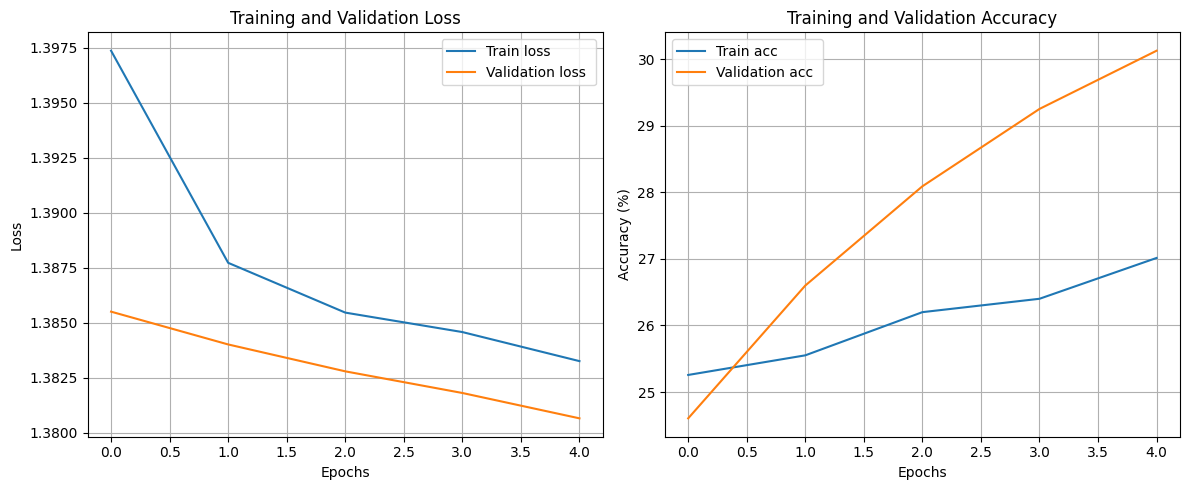

Transformation with trainable positional


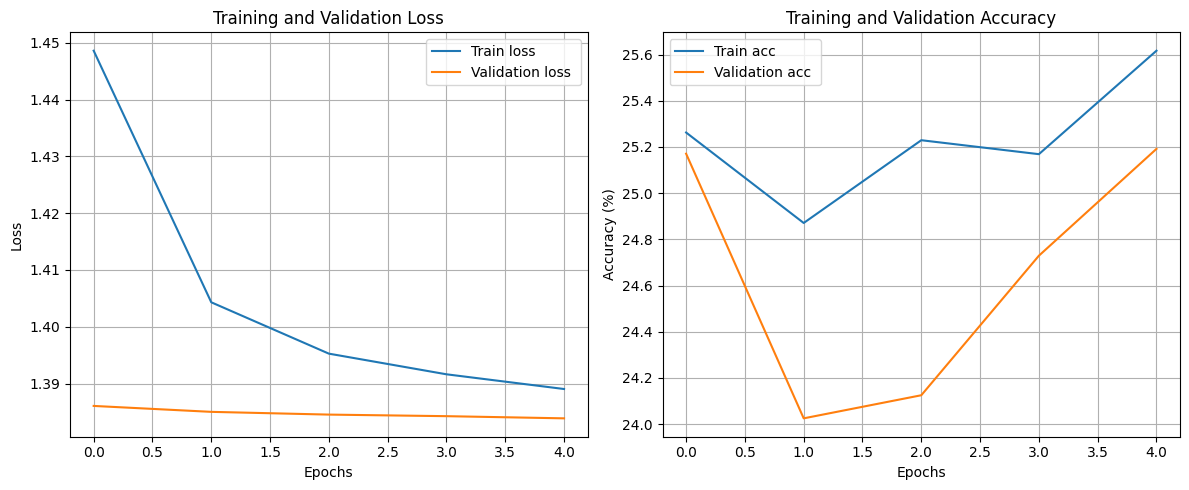

Transformation with no positional


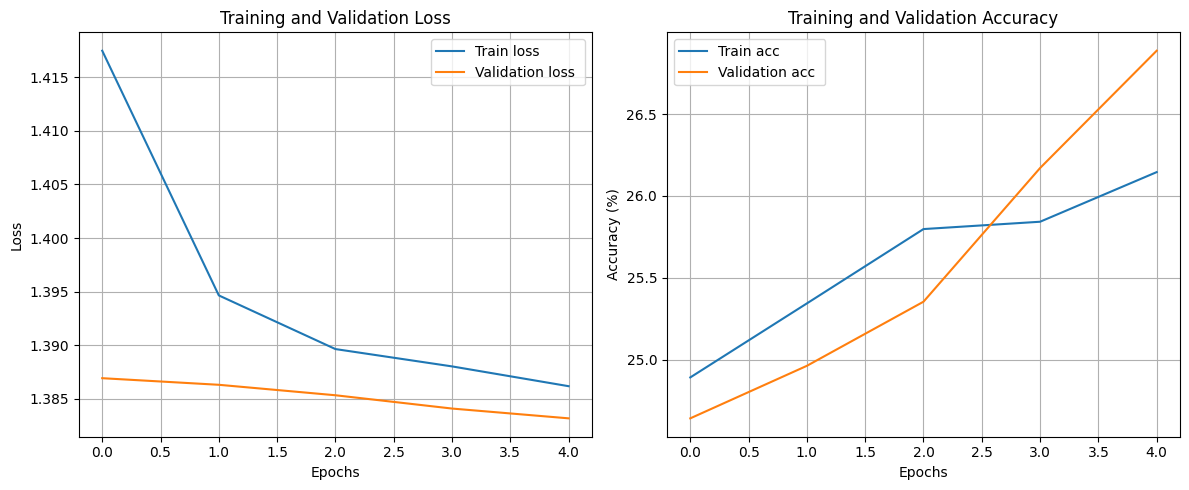

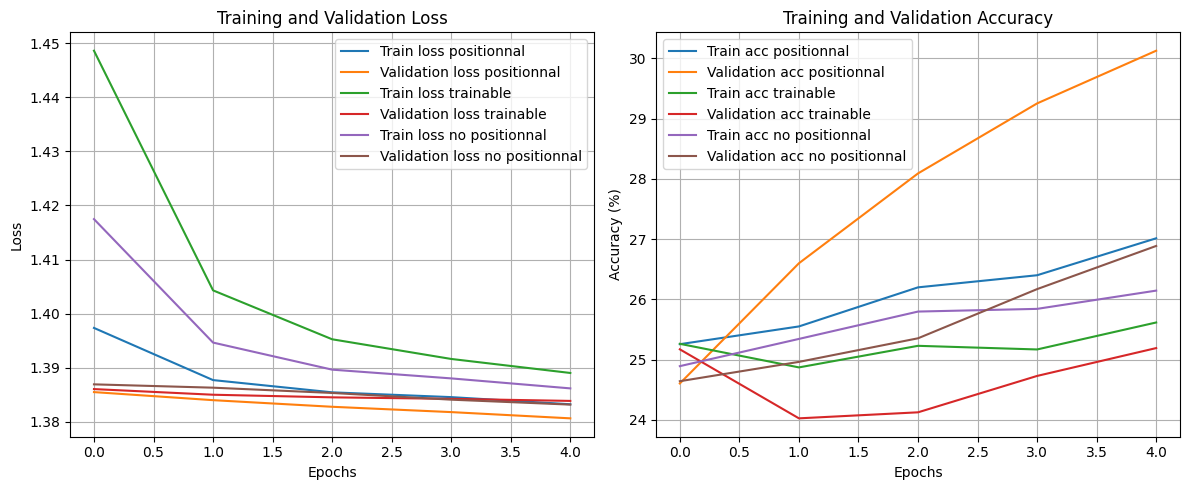

In [23]:
print("Transformation with classic positional")
plot_loss_with_validation(history_pos)
print("Transformation with trainable positional")
plot_loss_with_validation(history_trainable)
print("Transformation with no positional")
plot_loss_with_validation(history_nopos)
plot_loss_with_validation_all([(history_pos,'positionnal'), (history_trainable, 'trainable'), (history_nopos, 'no positionnal')])

## 3.8.2 Positional Encoding Exploration

In [24]:
# Get one batch of samples
inputs, targets = next(iter(train_loader))

# Model parameters
VOCAB_SIZE = len(vocab)
MAX_LEN = 256

EMBED_DIM = 32
NUM_HEADS = 4 # Number of attention heads
NUM_LAYERS = 2 # Number of encoder layers
FF_DIM = 32 # Dimension of the feedforward network
DROPOUT = 0.2
NUM_CLASSES = 4

EPOCHS = 5
LEARNING_RATE = 1e-3

model_pos2 = TransformerClassifier(
    vocabulary=vocab,
    max_len=MAX_LEN,
    embedding_dim=EMBED_DIM,
    num_heads=NUM_HEADS,
    ff_dim=FF_DIM,
    num_encoder_layers=NUM_LAYERS,
    num_classes=NUM_CLASSES,
    droprate=DROPOUT
).to(device)

loss_fn = nn.CrossEntropyLoss()
optimizer_pos = torch.optim.Adam(model_pos.parameters(), lr=LEARNING_RATE)

print(model_pos2)


TransformerClassifier(
  (embedding): Embedding(20002, 32)
  (pos_encoding): PositionalEncoding()
  (encoders): ModuleList(
    (0-1): 2 x EncoderLayer(
      (attention): MultiHeadSelfAttention(
        (query_linear): LazyLinear(in_features=0, out_features=32, bias=True)
        (key_linear): LazyLinear(in_features=0, out_features=32, bias=True)
        (value_linear): LazyLinear(in_features=0, out_features=32, bias=True)
        (output_linear): LazyLinear(in_features=0, out_features=32, bias=True)
      )
      (ffn): Sequential(
        (0): Linear(in_features=32, out_features=32, bias=True)
        (1): ReLU()
        (2): Linear(in_features=32, out_features=32, bias=True)
      )
      (norm1): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
      (norm2): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
      (dropout1): Dropout(p=0.2, inplace=False)
      (dropout2): Dropout(p=0.2, inplace=False)
    )
  )
  (pool): AdaptiveAvgPool1d(output_size=1)
  (dropout): Dropou

Dot products between the positional encoding vectors for all
pairs of positions

torch.Size([256, 32])


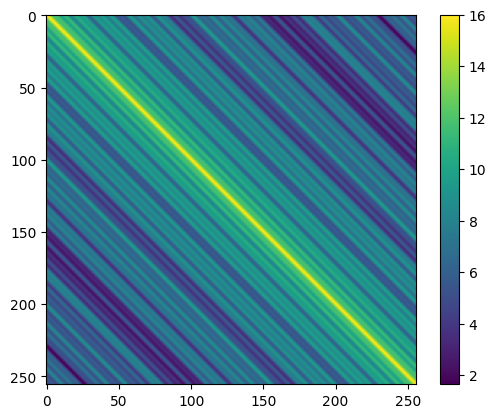

In [25]:
PE = model_pos2.pos_encoding.pe.squeeze(0)
print(PE.shape)

# dot product btw each position pair
D = PE @ PE.T
D

# heatmap
plt.imshow(D.cpu().numpy())
plt.colorbar()
plt.show()

Interpretation: parallel result: similarity of PE(i) . PE(j) is the same as the one of PE(j) . PE(i) 
  
=> The yellow diag confirms that the highest similarity is an encodding with himself.

Dot products
between the first position (position 0) and all other positions

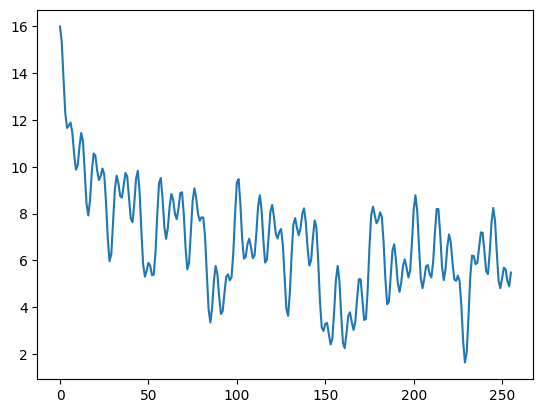

In [26]:

# dot product btw each position pair
D1 = PE[0] @ PE.T


# plot
plt.plot(D1.cpu().numpy())


Highest similarity with 0 (himself), then similarity varies. Decreases as the position is more far from the word which is a normal pattern for positionnal encoding: we cant the position to have an impact on the encoding.

## 3.8.3 Movie Sentiment Prediction with Transformers

#### Dataset

In [4]:
from datasets import load_dataset
dataset = load_dataset("stanfordnlp/imdb")
dataset_croped = dataset.copy()


In [5]:
train_labels = dataset["train"]["label"]

def normalize_string(s):
    """Normalize a string by lowercasing, trimming, and removing non-letter characters.

    Args:
        s (str): The input string to normalize.

    Returns:
        str: The normalized string.
    """
    s = s.lower().strip()
    # regex to replace any non-letter characters by white space
    s = re.sub(r"[^a-zA-Z!?]+", r" ", s)
    return s.strip()

MAX_LEN = max(
    len(normalize_string(text).split()) 
    for text in dataset["train"]["text"]
)
print(MAX_LEN) 
MAX_LEN_CROP = 300

print(set(train_labels))

2515
{0, 1}


In [6]:
temp = dataset["train"].train_test_split(test_size=0.2)
dataset['val'] = temp['test']
dataset['train'] = temp['train']
dataset_croped['val'] = temp['test']
dataset_croped['train'] = temp['train']

del temp

imbd_labels = {0: "Negative",
                 1: "Positive",
                 }

In [7]:
import re



def tokenize_and_trim(dataset, max_length=300):
    """ Tokenizes and trims the text in the dataset.
    Text is split at any whitespace character and trimmed to `max_length` number of tokens.

    Args:
        dataset (dict): A dictionary containing the dataset with a 'text' field.
        max_length (int, optional): Maximum number of tokens to keep. Defaults to 300.

    Returns:
        dict: A dictionary with 'text' field containing tokenized and trimmed text.
    """
    normalized_texts = [normalize_string(text) for text in dataset['text']]
    return {
        'text': [text.split()[:max_length] for text in normalized_texts]
        }

dataset['train'] = dataset['train'].map(
    lambda x: tokenize_and_trim(x, max_length=MAX_LEN),
    batched=True
)
dataset['val'] = dataset['val'].map(
    lambda x: tokenize_and_trim(x, max_length=MAX_LEN),
    batched=True
)
dataset['test'] = dataset['test'].map(
    lambda x: tokenize_and_trim(x, max_length=MAX_LEN),
    batched=True
)

dataset_croped['train'] = dataset_croped['train'].map(
    lambda x: tokenize_and_trim(x, max_length=MAX_LEN_CROP),
    batched=True
)
dataset_croped['val'] = dataset_croped['val'].map(
    lambda x: tokenize_and_trim(x, max_length=MAX_LEN_CROP),
    batched=True
)
dataset_croped['test'] = dataset_croped['test'].map(
    lambda x: tokenize_and_trim(x, max_length=MAX_LEN_CROP),
    batched=True
)

Map:   0%|          | 0/20000 [00:00<?, ? examples/s]

Map:   0%|          | 0/5000 [00:00<?, ? examples/s]

Map:   0%|          | 0/25000 [00:00<?, ? examples/s]

In [8]:
# check
print(len(max([dt for dt in dataset_croped['train']['text']])))

300


In [9]:
from tqdm.notebook import tqdm

class Vocabulary:
    """ A simple vocabulary class that builds a mapping from tokens to indices and vice versa.
    """

    def __init__(self, max_size):
        """ Initializes the vocabulary with a maximum size.
        Args:
            max_size (int): The maximum number of tokens to keep in the vocabulary.
        """
        self.max_size = max_size
        self.tokens_to_idx = {'<PAD>': 0, '<UNK>': 1}
        self.idx_to_tokens = {v:k for k,v in self.tokens_to_idx.items()}
        assert len(self.tokens_to_idx) == len(self.idx_to_tokens)

    def __len__(self):
        return len(self.tokens_to_idx)

    def build_vocabulary(self, dataset):
        """ Builds the vocabulary from the dataset.
        It counts the frequency of each token in the dataset and keeps the `max_size` most frequent tokens.
        Args:
            dataset (_type_): The dataset to build the vocabulary from.
        """
        print("Building vocabulary...")
        frequencies = {}
        idx = 2
        for sample in tqdm(dataset['text']):
            for word in sample:
                if word in frequencies:
                    frequencies[word] += 1
                else:
                    frequencies[word] = 1

        # keep `max_size` most frequent words
        frequencies = sorted(
            frequencies.items(),
            key=lambda item: item[1],
            reverse=True
        )

        for word, freq in frequencies[:self.max_size]:
            self.tokens_to_idx[word] = idx
            self.idx_to_tokens[idx] = word
            idx += 1

    def encode(self, sample):
        """ Encodes a sample (list of tokens) into a list of indices.
        If a token is not in the vocabulary, it is replaced by the index of the `<UNK>` token.
        Args:
            sample (list): A list of tokens to encode.
        Returns:
            list: A list of indices corresponding to the tokens in the sample.
        """
        encoded = []
        for word in sample:
            if word in self.tokens_to_idx.keys():
                encoded.append(self.tokens_to_idx[word])
            else:
                encoded.append(self.tokens_to_idx['<UNK>'])
        return encoded

In [10]:
vocab = Vocabulary(max_size=20000)
vocab.build_vocabulary(dataset['train'])

vocab_croped = Vocabulary(max_size=20000)
vocab_croped.build_vocabulary(dataset_croped['train'])

Building vocabulary...


  0%|          | 0/20000 [00:00<?, ?it/s]

Building vocabulary...


  0%|          | 0/20000 [00:00<?, ?it/s]

In [11]:
def encode_dataset(dataset):
    return {
        'encoded': [vocab.encode(text) for text in dataset['text']]
        }
def encode_dataset_croped(dataset):
    return {
        'encoded': [vocab_croped.encode(text) for text in dataset['text']]
        }


dataset['train'] = dataset['train'].map(encode_dataset, batched=True)
dataset['val'] = dataset['val'].map(encode_dataset, batched=True)
dataset['test'] = dataset['test'].map(encode_dataset, batched=True)
dataset_croped['train'] = dataset_croped['train'].map(encode_dataset_croped, batched=True)
dataset_croped['val'] = dataset_croped['val'].map(encode_dataset_croped, batched=True)
dataset_croped['test'] = dataset_croped['test'].map(encode_dataset_croped, batched=True)

Map:   0%|          | 0/20000 [00:00<?, ? examples/s]

Map:   0%|          | 0/5000 [00:00<?, ? examples/s]

Map:   0%|          | 0/25000 [00:00<?, ? examples/s]

Map:   0%|          | 0/20000 [00:00<?, ? examples/s]

Map:   0%|          | 0/5000 [00:00<?, ? examples/s]

Map:   0%|          | 0/25000 [00:00<?, ? examples/s]

In [12]:
from torch.utils.data import TensorDataset
import torch.nn.functional as F
import torch



def create_tensordataset(dataset):
    inputs = torch.nn.utils.rnn.pad_sequence(
        [torch.tensor(d) for d in dataset['encoded']],
        batch_first=True,
        padding_value=0,
        ### START YOUR CODE HERE ###
        # 'left' or 'right'?
        padding_side= 'left' # doesn't matter
        ### END YOUR CODE HERE ###
    )

    targets = torch.Tensor(dataset['label']).long()

    return TensorDataset(inputs.to(device), targets.to(device))

train_ds = create_tensordataset(dataset['train'])
val_ds = create_tensordataset(dataset['val'])
test_ds = create_tensordataset(dataset['test'])

train_ds_crop = create_tensordataset(dataset_croped['train'])
val_ds_crop = create_tensordataset(dataset_croped['val'])
test_ds_crop = create_tensordataset(dataset_croped['test'])

In [13]:
from torch.utils.data import DataLoader

BATCH_SIZE = 16

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE)

train_loader_crop = DataLoader(train_ds_crop, batch_size=BATCH_SIZE, shuffle=True)
val_loader_crop = DataLoader(val_ds_crop, batch_size=BATCH_SIZE)
test_loader_crop = DataLoader(test_ds_crop, batch_size=BATCH_SIZE)

### Model

In [14]:
import torch.nn as nn

class TransformerEncoderPyT(nn.Module):
  def __init__(self, vocabulary, max_len, embedding_dim, num_heads, num_layers, ff_dim, num_classes, droprate=.1):
    super().__init__()
    self.embedding = nn.Embedding(len(vocabulary), embedding_dim)
    self.pos_encoding = PositionalEncoding(max_len, embedding_dim)

    # Transformer encoder layer by PyTorch
    encoder_layer = nn.TransformerEncoderLayer(
        d_model=embedding_dim,
        nhead=num_heads,
        dim_feedforward=ff_dim,
        dropout=droprate,
        batch_first=True
    )
    self.transformer_encoder = nn.TransformerEncoder(
        encoder_layer,
        num_layers=num_layers
    )
    self.fc = nn.Linear(embedding_dim, num_classes)

  def forward(self, x, mask=None):
    # 1. The PyTorch TransformerEncoder expects a mask where True means to
    # **ignore** the position -> we need to invert our mask
    # 2. The expected mask shape is (batch_size, sequence_length) for `src_key_padding_mask`
    # our provided mask has shape (batch_size, 1, 1, sequence_length)
    if mask is not None:
        padding_mask = (mask.squeeze(1).squeeze(1) == 0)
    else:
        padding_mask = None

    x = self.embedding(x)
    x = self.pos_encoding(x)
    output = self.transformer_encoder(x, src_key_padding_mask=padding_mask)

    if padding_mask is not None:
        token_mask = (~padding_mask).unsqueeze(-1).float()  # (B, T, 1)
        mean_output = (output * token_mask).sum(dim=1) / token_mask.sum(dim=1).clamp(min=1)
    else:
        mean_output = output.mean(dim=1)

    return self.fc(mean_output)

### Original sequence length

In [39]:
import math

# Model parameters
EMBED_DIM = 32
NUM_HEADS = 4
NUM_LAYERS = 2
FF_DIM = 32
DROPOUT = 0.2
NUM_CLASSES = 2 # positive or negative: {0, 1}

EPOCHS = 5
LEARNING_RATE = 1e-3

PyTmodel_max = TransformerEncoderPyT(
    vocabulary=vocab,
    embedding_dim=EMBED_DIM,
    max_len=MAX_LEN,
    num_heads=NUM_HEADS,
    num_layers=NUM_LAYERS,
    ff_dim=FF_DIM,
    num_classes=NUM_CLASSES,
    droprate=DROPOUT,
).to(device)

loss_fn = nn.CrossEntropyLoss()
optimizer_max = torch.optim.Adam(PyTmodel_max.parameters(), lr=LEARNING_RATE)

print(PyTmodel_max)

TransformerEncoderPyT(
  (embedding): Embedding(20002, 32)
  (pos_encoding): PositionalEncoding()
  (transformer_encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=32, out_features=32, bias=True)
        )
        (linear1): Linear(in_features=32, out_features=32, bias=True)
        (dropout): Dropout(p=0.2, inplace=False)
        (linear2): Linear(in_features=32, out_features=32, bias=True)
        (norm1): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.2, inplace=False)
        (dropout2): Dropout(p=0.2, inplace=False)
      )
    )
  )
  (fc): Linear(in_features=32, out_features=2, bias=True)
)


### Cropped length

In [40]:


PyTmodel_crop = TransformerEncoderPyT(
    vocabulary=vocab_croped,
    embedding_dim=EMBED_DIM,
    max_len=MAX_LEN_CROP,
    num_heads=NUM_HEADS,
    num_layers=NUM_LAYERS,
    ff_dim=FF_DIM,
    num_classes=NUM_CLASSES,
    droprate=DROPOUT,
).to(device)

optimizer_crop = torch.optim.Adam(PyTmodel_crop.parameters(), lr=LEARNING_RATE)

print(PyTmodel_crop)

TransformerEncoderPyT(
  (embedding): Embedding(20002, 32)
  (pos_encoding): PositionalEncoding()
  (transformer_encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=32, out_features=32, bias=True)
        )
        (linear1): Linear(in_features=32, out_features=32, bias=True)
        (dropout): Dropout(p=0.2, inplace=False)
        (linear2): Linear(in_features=32, out_features=32, bias=True)
        (norm1): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.2, inplace=False)
        (dropout2): Dropout(p=0.2, inplace=False)
      )
    )
  )
  (fc): Linear(in_features=32, out_features=2, bias=True)
)


In [41]:
# Get one batch
inputs, targets = next(iter(train_loader))
print(f"Input shape: {inputs.shape}")

inputs_crop, targets = next(iter(train_loader_crop))
print(f"Input shape: {inputs_crop.shape}")

# Forward pass
outputs = PyTmodel_max(inputs)
outputs_croped = PyTmodel_crop(inputs_crop)

# Print shapes
print(f"Output shape: {outputs.shape}")
print(f"Target shape: {targets.shape}")

print(f"Output shape crop: {outputs_croped.shape}")
print(f"Target shape crop: {targets.shape}")

Input shape: torch.Size([16, 2515])
Input shape: torch.Size([16, 300])
Output shape: torch.Size([16, 2])
Target shape: torch.Size([16])
Output shape crop: torch.Size([16, 2])
Target shape crop: torch.Size([16])


In [42]:
def plot_sequence_embedding(input_sequence, model):

    input_sequence = input_sequence.unsqueeze(0) # Add batch dimension back
    print(f"Sample input sequence shape: {input_sequence.shape}")

    # Get the embedding layer from the model
    embedding_layer = model.embedding

    # Get the positional encoding layer from the model
    pos_encoding_layer = model.pos_encoding

    # Get the initial token embeddings
    initial_embeddings = embedding_layer(input_sequence)
    print(f"Initial embeddings shape: {initial_embeddings.shape}")

    # Apply positional encoding
    embeddings_with_pe = pos_encoding_layer(initial_embeddings)
    print(f"Embeddings with PE shape: {embeddings_with_pe.shape}")

    # --- Visualization for the entire sequence ---

    # Convert tensors to numpy arrays for plotting
    initial_embeddings_np = initial_embeddings[0].detach().cpu().numpy()
    embeddings_with_pe_np = embeddings_with_pe[0].detach().cpu().numpy()

    fig, axes = plt.subplots(2, 1, figsize=(18, 7))

    # Plot initial embeddings (full sequence)
    im1 = axes[0].imshow(initial_embeddings_np.T, aspect='auto')
    axes[0].set_title('Initial Embeddings (Full Sequence)')
    axes[0].set_xlabel('Token Position')
    axes[0].set_ylabel('Embedding Dimension')
    fig.colorbar(im1, ax=axes[0])

    # Plot embeddings with positional encoding (full sequence)
    im2 = axes[1].imshow(embeddings_with_pe_np.T, aspect='auto')
    axes[1].set_title('Embeddings + Positional Encoding (Full Sequence)')
    axes[1].set_xlabel('Token Position')
    axes[1].set_ylabel('Embedding Dimension')
    fig.colorbar(im2, ax=axes[1])

    plt.tight_layout()
    plt.show()

Input sequence shape (MAX): torch.Size([2515])
Sample input sequence shape: torch.Size([1, 2515])
Initial embeddings shape: torch.Size([1, 2515, 32])
Embeddings with PE shape: torch.Size([1, 2515, 32])


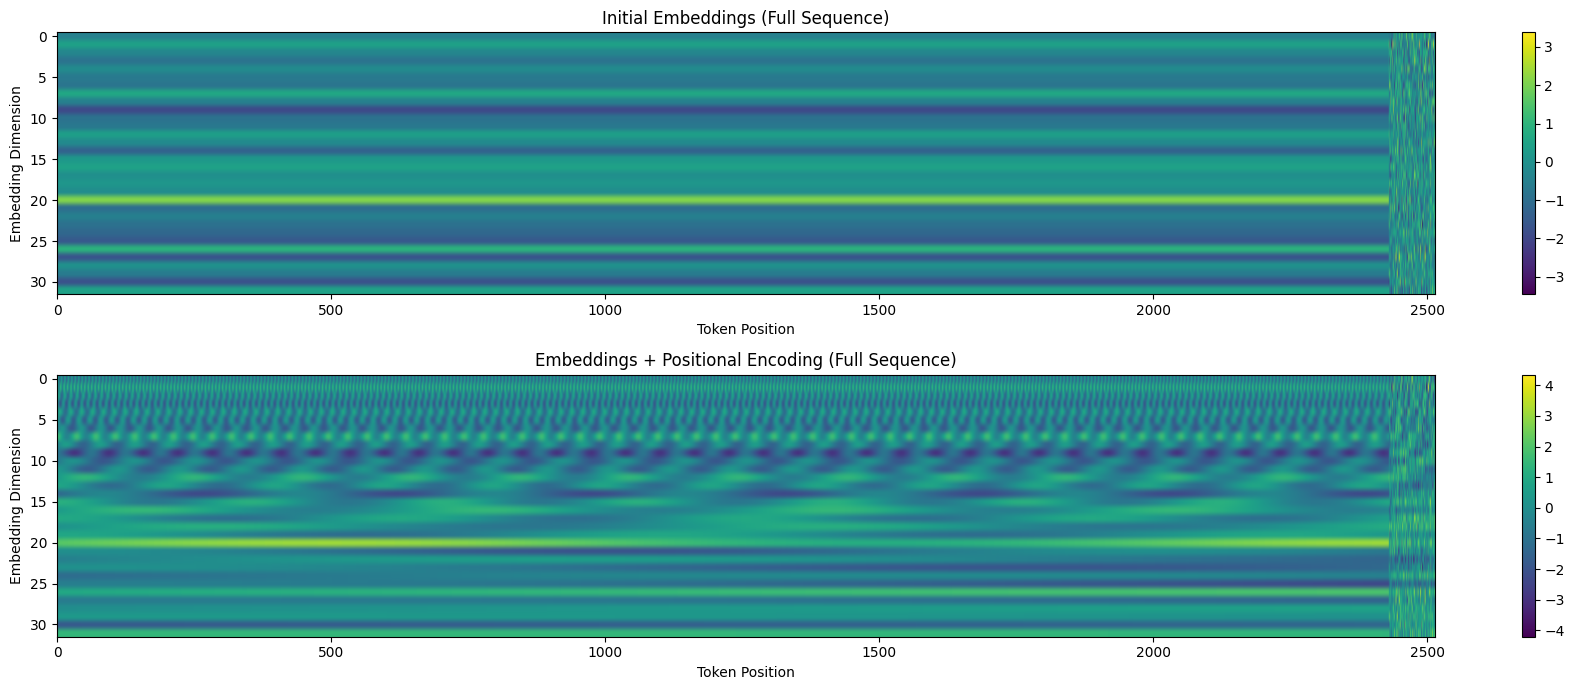

Input sequence shape (CROPED): torch.Size([300])
Sample input sequence shape: torch.Size([1, 300])
Initial embeddings shape: torch.Size([1, 300, 32])
Embeddings with PE shape: torch.Size([1, 300, 32])


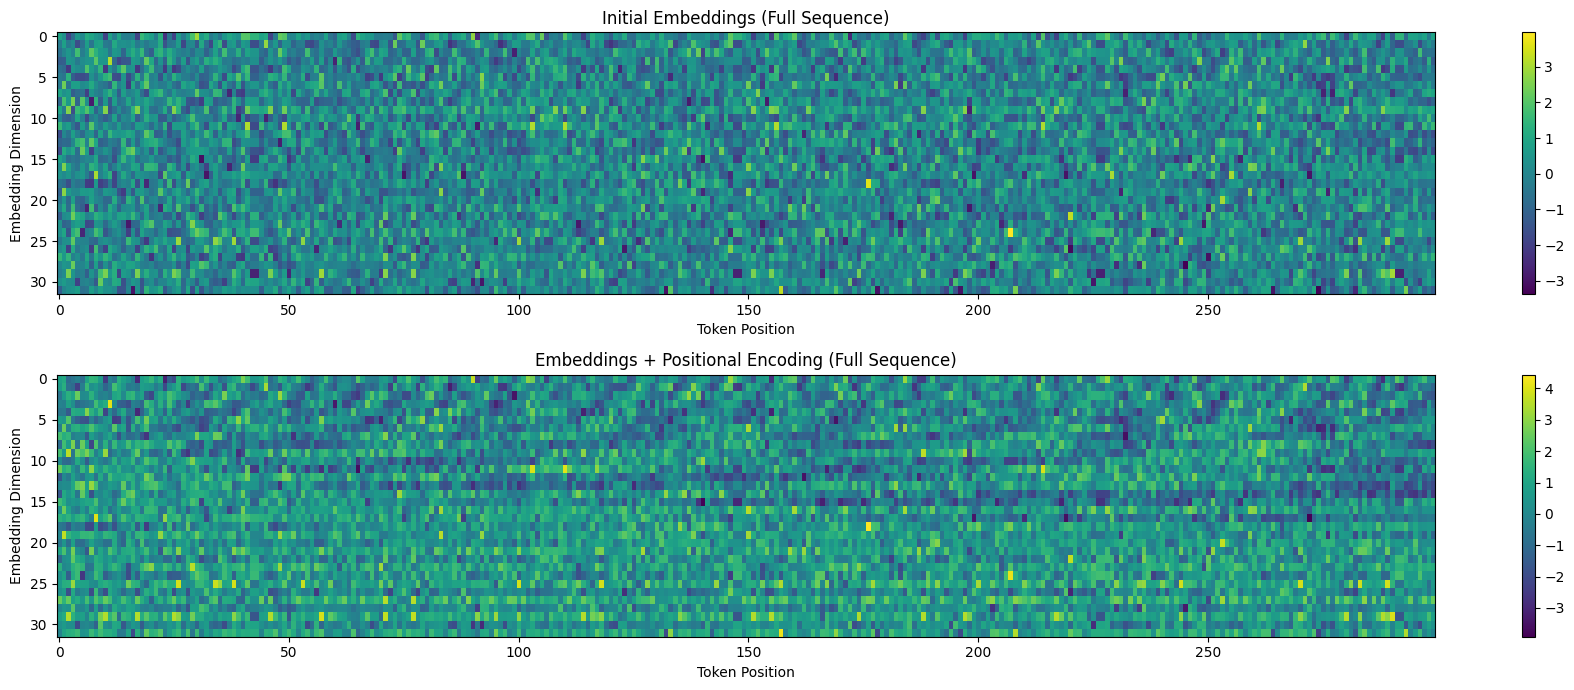

In [43]:
import matplotlib.pyplot as plt
input_sequence_max = inputs[0]
input_sequence_crop = inputs_crop[0]
print(f"Input sequence shape (MAX): {input_sequence_max.shape}")


plot_sequence_embedding(input_sequence_max, PyTmodel_max)
print(f"Input sequence shape (CROPED): {input_sequence_crop.shape}")
plot_sequence_embedding(input_sequence_crop, PyTmodel_crop)

### Training and evaluation

In [44]:
#@title Trainloop
from tqdm.notebook import tqdm
from matplotlib import pyplot as plt

def train_model_with_validation(model, optimizer, loss_fn, train_loader, val_loader, num_epochs=5, scheduler=None):
    model.train()
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': [], 'lr': []}

    for epoch in range(num_epochs):
        model.train()
        train_epoch_loss = 0.0
        correct_train = 0
        total_train = 0
        for data, targets in tqdm(train_loader, desc=f"Epoch {epoch+1} Training"):
            # generate a mask for padding tokens broadcastable to (batch_size, num_heads, sequence_length, sequence_length)
            # (data != 0) creates a boolean mask (batch_size, sequence_length)
            # .unsqueeze(1) -> (batch_size, 1, sequence_length)
            # .unsqueeze(2) -> (batch_size, 1, 1, sequence_length) which is broadcastable for key dimension masking
            padding_mask = (data != 0).unsqueeze(1).unsqueeze(2)

            logits = model(data, mask=padding_mask)
            running_loss = loss_fn(logits, targets)

            optimizer.zero_grad()
            running_loss.backward()
            optimizer.step()
            if scheduler is not None:
                scheduler.step()

            train_epoch_loss += running_loss.item()

            _, predicted = torch.max(logits.data, 1)
            total_train += targets.size(0)
            correct_train += (predicted == targets).sum().item()


        history['train_loss'].append(train_epoch_loss / len(train_loader))
        history['train_acc'].append(100 * correct_train / total_train)
        history['lr'].append(optimizer.param_groups[0]['lr'])


        model.eval()
        val_epoch_loss = 0.0
        correct_val = 0
        total_val = 0
        with torch.no_grad():
            for data, targets in tqdm(val_loader, desc=f"Epoch {epoch+1} Validation"):
                padding_mask = (data != 0).unsqueeze(1).unsqueeze(2)
                logits = model(data, mask=padding_mask)
                running_loss = loss_fn(logits, targets)
                val_epoch_loss += running_loss.item()

                _, predicted = torch.max(logits.data, 1)
                total_val += targets.size(0)
                correct_val += (predicted == targets).sum().item()

        history['val_loss'].append(val_epoch_loss / len(val_loader))
        history['val_acc'].append(100 * correct_val / total_val)

        print(f"Epoch {epoch + 1}/{num_epochs}",
              f"| Train Loss: {history['train_loss'][-1]:.4f}",
              f"| Train Acc: {history['train_acc'][-1]:.2f}%",
              f"| Val Loss: {history['val_loss'][-1]:.4f}",
              f"| Val Acc: {history['val_acc'][-1]:.2f}%",
              f"| LR: {history['lr'][-1]:.2e}", sep=" ")

    return history


def plot_loss_with_validation(history):
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(history['train_loss'], label='Train Loss')
    plt.plot(history['val_loss'], label='Validation Loss')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid()

    plt.subplot(1, 2, 2)
    plt.plot(history['train_acc'], label='Train Accuracy')
    plt.plot(history['val_acc'], label='Validation Accuracy')
    plt.title('Training and Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy (%)')
    plt.legend()
    plt.grid()

    plt.tight_layout()
    plt.show()

In [45]:
import math

LEARNING_RATE = 1e-3
WARMUP_RATIO = 0.1
USE_SCHEDULER = True

def lr_lambda(current_step):
    step = float(current_step + 1)  # +1 to avoid rsqrt(0) at step=0
    arg1 = step ** -0.5
    arg2 = step * (warmup_steps ** -1.5)
    return (EMBED_DIM ** -0.5) * min(arg1, arg2)

if USE_SCHEDULER:
    LEARNING_RATE = 1.0 # lr_lambda returns the absolute lr; base must be 1.0
    total_steps = EPOCHS * len(train_loader)
    warmup_steps = max(1, int(total_steps * WARMUP_RATIO))
    scheduler_max = torch.optim.lr_scheduler.LambdaLR(optimizer_max, lr_lambda=lr_lambda)
    scheduler_crop = torch.optim.lr_scheduler.LambdaLR(optimizer_crop, lr_lambda=lr_lambda)


    lrs = []
    for step in range(total_steps):
        lrs.append(lr_lambda(step))
    # plt.plot(lrs)
    # plt.title("Learning Rate Schedule")
    # plt.xlabel("Training Steps")
    # plt.ylabel("Learning Rate Multiplier")
    # plt.grid()
    # plt.show()

else:
    scheduler = None

criterion = nn.CrossEntropyLoss()


Epoch 1 Training:   0%|          | 0/1250 [00:00<?, ?it/s]

Epoch 1 Validation:   0%|          | 0/313 [00:00<?, ?it/s]

Epoch 1/5 | Train Loss: 0.6926 | Train Acc: 51.73% | Val Loss: 0.7014 | Val Acc: 50.28% | LR: 5.00e-06


Epoch 2 Training:   0%|          | 0/1250 [00:00<?, ?it/s]

Epoch 2 Validation:   0%|          | 0/313 [00:00<?, ?it/s]

...

Epoch 4 Validation:   0%|          | 0/313 [00:00<?, ?it/s]

Epoch 4/5 | Train Loss: 0.6907 | Train Acc: 52.83% | Val Loss: 0.7000 | Val Acc: 50.74% | LR: 2.50e-06


Epoch 5 Training:   0%|          | 0/1250 [00:00<?, ?it/s]

Epoch 5 Validation:   0%|          | 0/313 [00:00<?, ?it/s]

Epoch 5/5 | Train Loss: 0.6905 | Train Acc: 52.62% | Val Loss: 0.6996 | Val Acc: 50.68% | LR: 2.24e-06


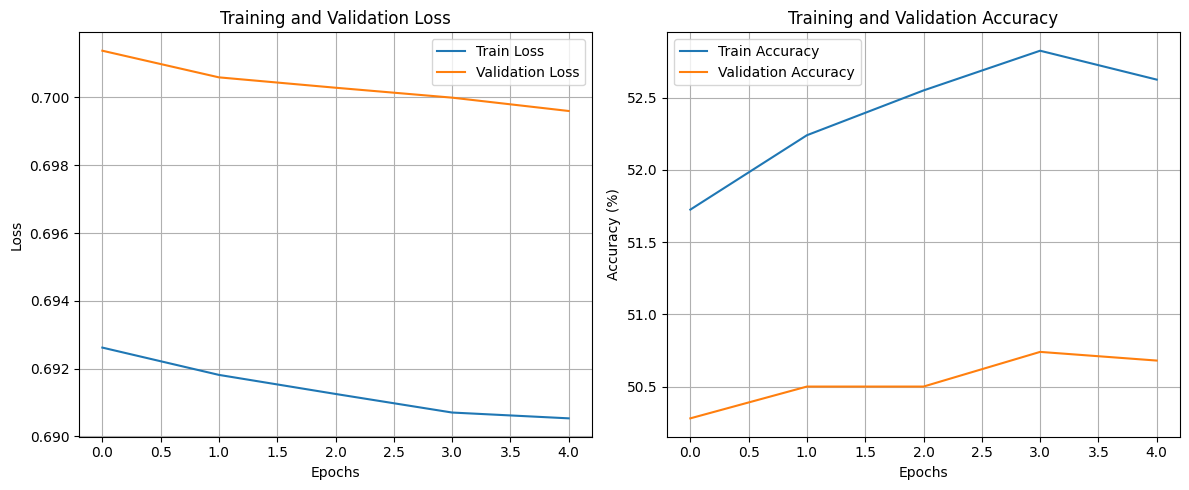

In [46]:
history_max = train_model_with_validation(
    PyTmodel_max,
    optimizer_max,
    criterion,
    train_loader,
    val_loader,
    num_epochs=5,
    scheduler=scheduler_max
)
plot_loss_with_validation(history_max)



Epoch 1 Training:   0%|          | 0/1250 [00:00<?, ?it/s]

Epoch 1 Validation:   0%|          | 0/313 [00:00<?, ?it/s]

Epoch 1/5 | Train Loss: 0.6984 | Train Acc: 50.47% | Val Loss: 0.6934 | Val Acc: 50.76% | LR: 5.00e-06


Epoch 2 Training:   0%|          | 0/1250 [00:00<?, ?it/s]

Epoch 2 Validation:   0%|          | 0/313 [00:00<?, ?it/s]

...

Epoch 4 Validation:   0%|          | 0/313 [00:00<?, ?it/s]

Epoch 4/5 | Train Loss: 0.6910 | Train Acc: 53.18% | Val Loss: 0.6913 | Val Acc: 52.44% | LR: 2.50e-06


Epoch 5 Training:   0%|          | 0/1250 [00:00<?, ?it/s]

Epoch 5 Validation:   0%|          | 0/313 [00:00<?, ?it/s]

Epoch 5/5 | Train Loss: 0.6906 | Train Acc: 53.70% | Val Loss: 0.6909 | Val Acc: 53.06% | LR: 2.24e-06


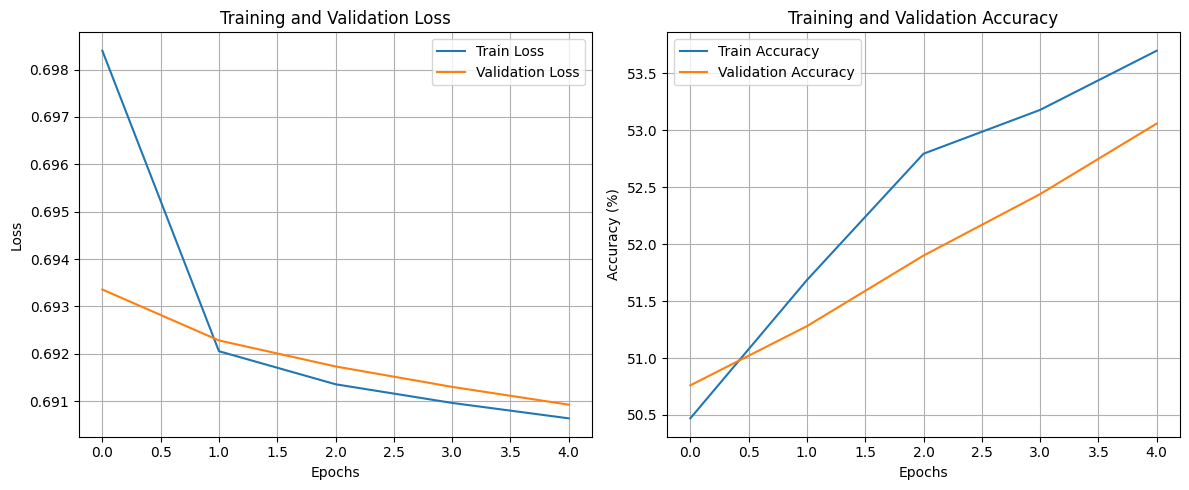

In [47]:
history_crop = train_model_with_validation(
    PyTmodel_crop,
    optimizer_crop,
    criterion,
    train_loader_crop,
    val_loader_crop,
    num_epochs=5,
    scheduler=scheduler_crop
)
plot_loss_with_validation(history_crop)

#### Training times

original length -> really long: 21min
cropped length: 1m49